In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Google Sheet CSV link
url = "https://docs.google.com/spreadsheets/d/1RwlkHOzSf2OQ2k_8Wp3k9gLU9fCS9M_F8OD-cCmOovU/export?format=csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (418, 12)

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


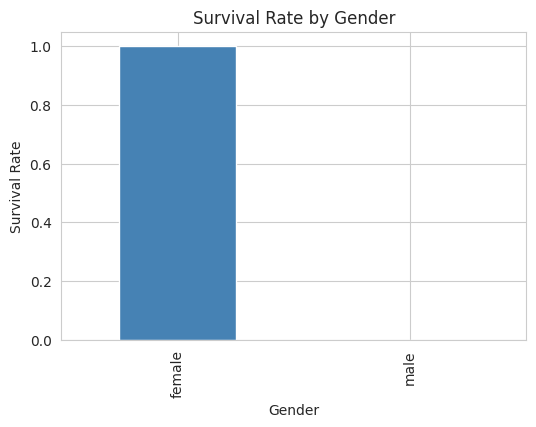

In [5]:
survival_sex = df.groupby("Sex")["Survived"].mean()

plt.figure(figsize=(6,4))
survival_sex.plot(kind="bar", color=["steelblue","orange"])

plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.xlabel("Gender")

plt.show()

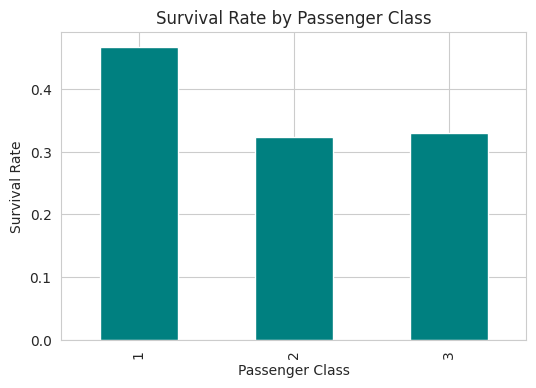

In [6]:
survival_class = df.groupby("Pclass")["Survived"].mean()

plt.figure(figsize=(6,4))
survival_class.plot(kind="bar", color="teal")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

/tmp/ipykernel_824/2762378327.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby("AgeGroup")["Survived"].mean()


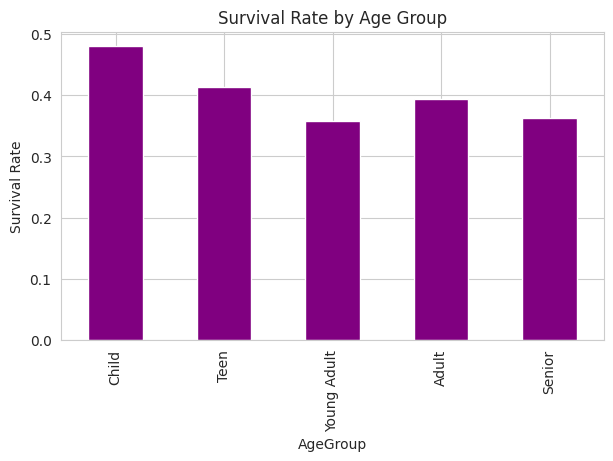

In [7]:

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,35,60,100],
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)

age_survival = df.groupby("AgeGroup")["Survived"].mean()

plt.figure(figsize=(7,4))
age_survival.plot(kind="bar", color="purple")

plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Rate")

plt.show()

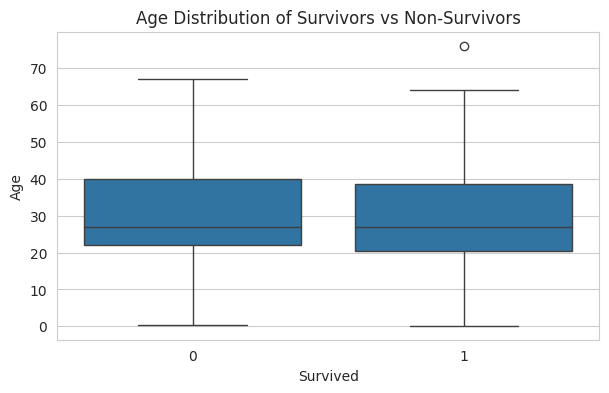

In [8]:
plt.figure(figsize=(7,4))

sns.boxplot(x="Survived", y="Age", data=df)

plt.title("Age Distribution of Survivors vs Non-Survivors")

plt.show()

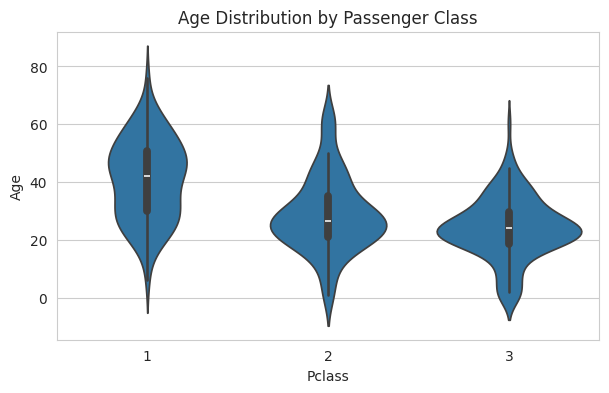

In [9]:
plt.figure(figsize=(7,4))

sns.violinplot(x="Pclass", y="Age", data=df)

plt.title("Age Distribution by Passenger Class")

plt.show()